# LightGBM Classification Solutions

![Namespace Labs](../../../../labs.png)

## Churn Prediction

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Read in churn.csv
df = pd.read_csv('churn.csv', nrows=1000)

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# check the head of the loaded dataframe


<Axes: xlabel='Churn', ylabel='count'>

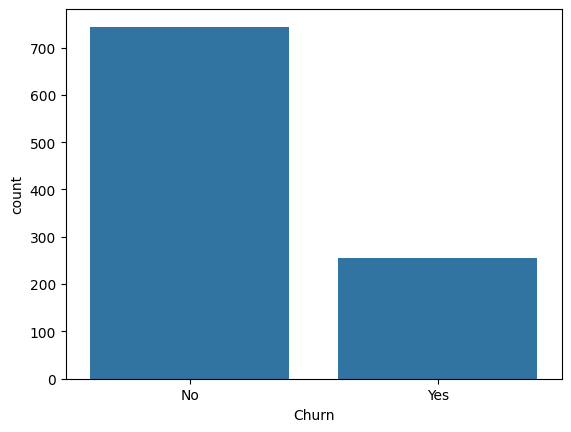

In [6]:
sns.countplot(data=df, x='Churn')

In [7]:
# Plot the graph below


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        1000 non-null   object 
 1   gender            1000 non-null   object 
 2   SeniorCitizen     1000 non-null   int64  
 3   Partner           1000 non-null   object 
 4   Dependents        1000 non-null   object 
 5   tenure            1000 non-null   int64  
 6   PhoneService      1000 non-null   object 
 7   MultipleLines     1000 non-null   object 
 8   InternetService   1000 non-null   object 
 9   OnlineSecurity    1000 non-null   object 
 10  OnlineBackup      1000 non-null   object 
 11  DeviceProtection  1000 non-null   object 
 12  TechSupport       1000 non-null   object 
 13  StreamingTV       1000 non-null   object 
 14  StreamingMovies   1000 non-null   object 
 15  Contract          1000 non-null   object 
 16  PaperlessBilling  1000 non-null   object 
 

In [9]:
# Create a dataframe called cat_feats
# It should contain all the categorical features of the 
# Data Frame
cat_feats = ['Partner','gender','SeniorCitizen','Dependents','PhoneService','MultipleLines',
             'InternetService','OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod' ]

In [10]:
# Convert Churn into a dummy variable
dff = pd.get_dummies(data=df, columns=['Churn'], drop_first=True)

In [30]:
dff.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        1000 non-null   object 
 1   gender            1000 non-null   object 
 2   SeniorCitizen     1000 non-null   int64  
 3   Partner           1000 non-null   object 
 4   Dependents        1000 non-null   object 
 5   tenure            1000 non-null   int64  
 6   PhoneService      1000 non-null   object 
 7   MultipleLines     1000 non-null   object 
 8   InternetService   1000 non-null   object 
 9   OnlineSecurity    1000 non-null   object 
 10  OnlineBackup      1000 non-null   object 
 11  DeviceProtection  1000 non-null   object 
 12  TechSupport       1000 non-null   object 
 13  StreamingTV       1000 non-null   object 
 14  StreamingMovies   1000 non-null   object 
 15  Contract          1000 non-null   object 
 16  PaperlessBilling  1000 non-null   object 
 

In [46]:
from category_encoders import OrdinalEncoder
enc = OrdinalEncoder(cols=cat_feats, handle_missing='return_nan', handle_unknown='return_nan')
enc.fit(dff)
dff_transformed = enc.transform(dff)
dff_transformed.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn_Yes
0,7590-VHVEG,1.0,1.0,1.0,1.0,1,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,29.85,29.85,0
1,5575-GNVDE,2.0,1.0,2.0,1.0,34,2.0,2.0,1.0,2.0,...,2.0,1.0,1.0,1.0,2.0,2.0,2.0,56.95,1889.50,0
2,3668-QPYBK,2.0,1.0,2.0,1.0,2,2.0,2.0,1.0,2.0,...,1.0,1.0,1.0,1.0,1.0,1.0,2.0,53.85,108.15,1
3,7795-CFOCW,2.0,1.0,2.0,1.0,45,1.0,1.0,1.0,2.0,...,2.0,2.0,1.0,1.0,2.0,2.0,3.0,42.30,1840.75,0
4,9237-HQITU,1.0,1.0,2.0,1.0,2,2.0,2.0,2.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,70.70,151.65,1


In [13]:
# Convert the categories into integers
# Display the head of the converted dataframe

In [58]:
# Create the X variable
X = dff_transformed.drop(['customerID', 'Churn_Yes'], axis=1)
X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,1.0,1.0,1.0,1.0,1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,29.85,29.85
1,2.0,1.0,2.0,1.0,34,2.0,2.0,1.0,2.0,2.0,2.0,1.0,1.0,1.0,2.0,2.0,2.0,56.95,1889.50
2,2.0,1.0,2.0,1.0,2,2.0,2.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,53.85,108.15
3,2.0,1.0,2.0,1.0,45,1.0,1.0,1.0,2.0,2.0,2.0,2.0,1.0,1.0,2.0,2.0,3.0,42.30,1840.75
4,1.0,1.0,2.0,1.0,2,2.0,2.0,2.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,70.70,151.65


In [59]:
# Create the y variable
y = dff_transformed.Churn_Yes
y.head()

0    0
1    0
2    1
3    0
4    1
Name: Churn_Yes, dtype: uint8

In [60]:
# Split the data into a training and testing set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [54]:
# Import LGBMClassifier
from lightgbm import LGBMClassifier

In [55]:
# Create an instance of LGBMClassifier
model = LGBMClassifier()

In [61]:
# Fit the data to the training set
model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 175, number of negative: 495
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.026798 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 578
[LightGBM] [Info] Number of data points in the train set: 670, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.261194 -> initscore=-1.039772
[LightGBM] [Info] Start training from score -1.039772
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

LGBMClassifier()

In [62]:
# Make predctions
# Store the predictions in a variable
predictions = model.predict(X_test)

In [66]:
# import the common classification metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

In [68]:
# Check the model's accuracy
accuracy_score(y_test, predictions)

0.806060606060606

In [72]:
# Print the confusion Matrix
confusion_matrix(y_test, predictions)

array([[225,  24],
       [ 40,  41]])

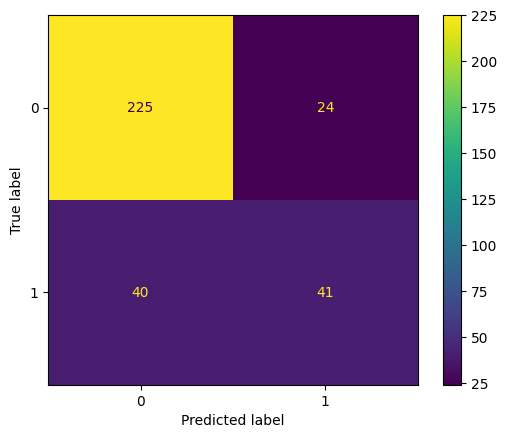

In [73]:
# Plot the confussion matrix
cm = confusion_matrix(y_test, predictions, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot()

In [75]:
# Print the classification report
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.85      0.90      0.88       249
           1       0.63      0.51      0.56        81

    accuracy                           0.81       330
   macro avg       0.74      0.70      0.72       330
weighted avg       0.80      0.81      0.80       330



Happy Coding!